# EGX360 crypto(btc) — THE DEEP QUANT MODEL (V8.4)
### Enhancing Down-Trend Detection & Bias Control in the Crypto

## 1. Environment Setup & Initialization

In [119]:
import tensorflow as tf
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"Success! GPU found: {gpu_devices}")
else:
    print("Still not working. Check PATH or CUDA version.")

Still not working. Check PATH or CUDA version.


In [120]:
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import joblib
import warnings
warnings.filterwarnings('ignore')

## 2. Data Loading & Raw Market Visualization
We begin by loading the BTC daily data. Financial time series data is notoriously noisy. Visualizing the raw candlesticks demonstrates why predicting raw daily closing prices is ineffective; the high volatility creates market noise that confuses standard predictive models.

In [121]:
df = pd.read_csv("BTC_all_daily.csv")
df_fng = pd.read_csv("Fear_Greed_Daily.csv") 

df['timestamp'] = pd.to_datetime(df['timestamp'])
df_fng['timestamp'] = pd.to_datetime(df_fng['timestamp']) 

In [122]:
df.sort_values('timestamp', inplace=True)
df_fng.sort_values('timestamp', inplace=True)
df = pd.merge_asof(df, df_fng, on='timestamp', direction='backward') 

print("Data Loaded Successfully. Shape:", df.shape)
print(f"Missing values before cleaning:\n{df.isnull().sum()}")


Data Loaded Successfully. Shape: (4189, 7)
Missing values before cleaning:
timestamp              0
open                   0
high                   0
low                    0
close                  0
volume                 0
Fear_Greed_Index    1233
dtype: int64


In [123]:
df.dropna(inplace=True)
df.sort_index(inplace=True)

In [124]:
df.head()


,timestamp,open,high,low,close,volume,Fear_Greed_Index
1233,2018-02-01,10237.299805,10288.799805,8812.280273,9170.540039,9959400448,30.0
1234,2018-02-02,9142.280273,9142.280273,7796.490234,8830.750000,12726899712,15.0
1235,2018-02-03,8852.120117,9430.750000,8251.629883,9174.910156,7263790080,40.0
1236,2018-02-04,9175.700195,9334.870117,8031.220215,8277.009766,7073549824,24.0
1237,2018-02-05,8270.540039,8364.839844,6756.680176,6955.270020,9285289984,11.0


In [125]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2956 entries, 1233 to 4188
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   timestamp         2956 non-null   datetime64[us]
 1   open              2956 non-null   float64       
 2   high              2956 non-null   float64       
 3   low               2956 non-null   float64       
 4   close             2956 non-null   float64       
 5   volume            2956 non-null   int64         
 6   Fear_Greed_Index  2956 non-null   float64       
dtypes: datetime64[us](1), float64(5), int64(1)
memory usage: 161.8 KB


In [126]:
df.describe()


,timestamp,open,high,low,close,volume,Fear_Greed_Index
count,2956,2956.000000,2956.000000,2956.000000,2956.000000,2.956000e+03,2956.000000
mean,2022-02-17 12:00:00,38430.499996,39185.095490,37622.589846,38449.023943,3.073295e+10,46.557848
min,2018-02-01 00:00:00,3236.274658,3275.377930,3191.303467,3236.761719,2.923670e+09,5.000000
25%,2020-02-09 18:00:00,9522.637451,9694.388428,9311.406738,9522.022461,1.562808e+10,27.000000
50%,2022-02-17 12:00:00,28420.998047,28915.107422,27904.105469,28419.224609,2.663701e+10,46.000000
75%,2024-02-26 06:00:00,59415.090820,61071.646484,58372.968750,59482.592773,4.058717e+10,65.000000
max,2026-03-06 00:00:00,124752.140625,126198.070312,123196.046875,124752.531250,3.509679e+11,95.000000
std,NaN,32553.082131,33079.294763,31977.627654,32553.202378,2.211644e+10,21.903890


In [127]:
sample_df = df.tail(150)
fig_raw = go.Figure(data=[go.Candlestick(x=sample_df['timestamp'],
                open=sample_df['open'],
                high=sample_df['high'],
                low=sample_df['low'],
                close=sample_df['close'])])

In [128]:
fig_raw.update_layout(title='EGX30 Raw Data - The Challenge of Market Noise',
                  yaxis_title='Price (EGP)',
                  xaxis_rangeslider_visible=False,
                  template='plotly_white')
fig_raw.show()

## 3. Advanced Feature Engineering (The Quant Indicators)
To make the data machine-readable, we engineer quantitative features. We translate raw price action into mathematical signals representing Trend, Momentum, and Volatility.

### A. Log Returns & Price Velocity
**Concept:** Absolute price changes are not statistically comparable over time. Logarithmic returns stabilize the variance. **Price Velocity** (the derivative of log returns) acts as an early warning system for market crashes.

**Mathematical Formula:**
$$R_t = \ln\left(\frac{P_t + \epsilon}{P_{t-1} + \epsilon}\right)$$
$$V_t = R_t - R_{t-1}$$

### Log Returns & Momentum Acceleration (Epsilon added to prevent Infinity)


In [129]:
df['log_ret'] = np.log((df['close'] + 1e-6) / (df['close'].shift(1) + 1e-6))
df['vol_log_ret'] = np.log((df['volume'] + 1e-6) / (df['volume'].shift(1) + 1e-6))



### Price Velocity


In [130]:
df['price_velocity'] = df['log_ret'].diff()


### B. Cyclic Time Features
**Concept:** Tree-based models do not intuitively understand weekly cycles. By mapping days to continuous sine and cosine waves, the model captures the "Day-of-the-Week" effect and institutional trading behaviors.

**Mathematical Formula:**
$$X_{sin} = \sin\left(\frac{2\pi \cdot d}{7}\right), \quad X_{cos} = \cos\left(\frac{2\pi \cdot d}{7}\right)$$

### Cyclic Time Features

In [131]:
df['day_sin'] = np.sin(2 * np.pi * df['timestamp'].dt.dayofweek / 7)
df['day_cos'] = np.cos(2 * np.pi * df['timestamp'].dt.dayofweek / 7)

### C. Exponential Moving Averages (EMA) & Gap Analysis
**Concept:** The EMA assigns exponentially greater weight to recent prices, making it highly responsive to new trends. We quantify over-extensions by measuring the percentage distance between the current price and the EMA.

**Mathematical Formula:**
$$EMA_t = \left( P_t \times \alpha \right) + \left( EMA_{t-1} \times (1 - \alpha) \right)$$

### The Winning EMAs & Trend Sensors

In [132]:
for period in [9, 21, 50]:
    ema_col = f'EMA_{period}'
    df[ema_col] = df['close'].ewm(span=period).mean()
    df[f'dist_EMA_{period}'] = (df['close'] - df[ema_col]) / (df[ema_col] + 1e-9)

### Critical Downtrend Sensor: Binary flag if price breaks below the fast EMA

In [133]:
df['below_EMA9'] = (df['close'] < df['EMA_9']).astype(int)

### D. Momentum & Panic Detectors (RSI, MACD, Bollinger Bands)
**Concept:** * **RSI & RSI_diff:** Measures buying/selling exhaustion.
* **Bollinger Band Width ($BB_{width}$):** Measures market "squeeze". Narrow bands mathematically precede explosive market volatility.

### Momentum (RSI & MACD)

In [134]:
delta = df['close'].diff()
gain = delta.where(delta > 0, 0).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
df['RSI'] = 100 - (100 / (1 + gain/(loss + 1e-9)))
df['RSI_diff'] = df['RSI'].diff()

In [135]:
macd = df['close'].ewm(span=12).mean() - df['close'].ewm(span=26).mean()
df['MACD_Hist'] = macd - macd.ewm(span=9).mean()

### Volatility (ATR)

In [136]:
tr = pd.concat([df['high'] - df['low'], 
                np.abs(df['high'] - df['close'].shift()), 
                np.abs(df['low'] - df['close'].shift())], axis=1).max(axis=1)
df['ATR_pct'] = tr.rolling(14).mean() / (df['close'] + 1e-9)

### Panic Detectors (Stochastic & Bollinger Bands)

In [137]:
low_14 = df['low'].rolling(14).min()
high_14 = df['high'].rolling(14).max()
df['Stoch_K'] = 100 * ((df['close'] - low_14) / (high_14 - low_14 + 1e-9))

In [138]:
ma20 = df['close'].rolling(20).mean()
std20 = df['close'].rolling(20).std()
df['BB_Width'] = (std20 * 4) / (ma20 + 1e-9)


### Temporal Lags

In [139]:
df['log_ret_lag1'] = df['log_ret'].shift(1)
df['RSI_lag1'] = df['RSI'].shift(1)

In [140]:
# --- إضافة مؤشرات الماكرو وتوقع النطاق السعري ---
df['SMA_200'] = df['close'].rolling(200).mean()

# حفظ قيمة الـ ATR كفلوس (لأننا هنحسب بيها رينج بكرة)
df['ATR_value'] = tr.rolling(14).mean()

# حذف القيم الفارغة الناتجة عن المتوسطات الجديدة
df.dropna(inplace=True)

## 4. Visualizing the Quant Transformation
Now that we have engineered our features, we overlay the Mathematical Signals (EMAs and Bollinger Bands) onto the raw candlesticks. This shows how the algorithms filter out the noise and identify structural bounds and trend directions.

### Visualizing the features applied to the price

In [141]:
sample_df = df.tail(150)
fig_quant = go.Figure()

### Base Price Candlesticks

In [142]:
fig_quant.add_trace(go.Candlestick(x=sample_df['timestamp'],
                open=sample_df['open'], high=sample_df['high'],
                low=sample_df['low'], close=sample_df['close'], name='Price'))

### Adding Trend Indicators (EMAs)

In [143]:
fig_quant.add_trace(go.Scatter(x=sample_df['timestamp'], y=sample_df['EMA_9'], line=dict(color='blue', width=1.5), name='EMA 9 (Fast)'))
fig_quant.add_trace(go.Scatter(x=sample_df['timestamp'], y=sample_df['EMA_50'], line=dict(color='orange', width=2), name='EMA 50 (Trend)'))

### Adding Volatility Bounds (Bollinger Bands)

In [144]:
ma20_sample = sample_df['close'].rolling(20).mean()
std20_sample = sample_df['close'].rolling(20).std()
fig_quant.add_trace(go.Scatter(x=sample_df['timestamp'], y=ma20_sample + (std20_sample*2), line=dict(color='rgba(128,128,128,0.5)', dash='dash'), name='Upper BB'))
fig_quant.add_trace(go.Scatter(x=sample_df['timestamp'], y=ma20_sample - (std20_sample*2), line=dict(color='rgba(128,128,128,0.5)', dash='dash'), name='Lower BB', fill='tonexty', fillcolor='rgba(128,128,128,0.1)'))

In [145]:
fig_quant.update_layout(title='Translating Noise into Mathematical Signals (EMAs & Volatility Bounds)', 
                        yaxis_title='Price (EGP)',
                        xaxis_rangeslider_visible=False,
                        template='plotly_white')
fig_quant.show()

## 5. Target Engineering & Data Cleaning
**Concept:** Predicting raw daily closing prices essentially models a Random Walk. By setting the target as the future direction of the $EMA_{10}$, we train the model to predict the *underlying trend mechanics*, pushing accuracy beyond 80%.

**Mathematical Formula for Target:**
$$Target = \begin{cases} 1 & \text{if } EMA_{10}(P_{t+1}) > EMA_{10}(P_t) \\ 0 & \text{otherwise} \end{cases}$$

### Target: Will the EMA rise tomorrow?

In [146]:
df['Target'] = (df['close'].ewm(span=10).mean().shift(-1) > df['close'].ewm(span=10).mean()).astype(int)


In [147]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

In [148]:
final_features = [
    'log_ret', 'vol_log_ret', 'price_velocity',
    'day_sin', 'day_cos', 
    'dist_EMA_9', 'dist_EMA_21', 'dist_EMA_50', 'below_EMA9',
    'RSI', 'RSI_diff', 'MACD_Hist', 'ATR_pct',
    'Stoch_K', 'BB_Width',
    'log_ret_lag1', 'RSI_lag1', 
    'SMA_200' # إضافة الفلتر الماكرو كـ Feature
]

X = df[final_features].values
y = df['Target'].values

## 6. Machine Learning: Splitting, Scaling & Stacking Ensemble
**Concept:** We use a chronological split (80/20) to prevent future data leakage. We then utilize an Ensemble Stacking algorithm. Because financial datasets exhibit an inherent upward bias, the Logistic Regression meta-learner applies a 50% higher penalty for missing a "Down-Trend" (`class_weight={0: 1.5}`). This strict risk management dramatically improves the Recall for market crashes.

### Train/Test Split (Chronological)

In [149]:
split = int(len(X) * 0.80)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


### Scaling

In [150]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
joblib.dump(scaler, "egx360_scaler_quant.pkl")

['egx360_scaler_quant.pkl']

### Stacking Ensemble

In [151]:
from sklearn.ensemble import RandomForestClassifier


print("🧠 Training The Smart Quant Ensemble (V8.4)...")

base_models = [
    ('xgb', xgb.XGBClassifier(n_estimators=600, max_depth=6, learning_rate=0.03, subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric='logloss')),
    ('lgbm', lgb.LGBMClassifier(n_estimators=600, max_depth=6, learning_rate=0.03, subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1)),
    ('rf', RandomForestClassifier(n_estimators=400, max_depth=8, random_state=42))
]

🧠 Training The Smart Quant Ensemble (V8.4)...


### Meta-learner with Bias Control (Over-penalizing the model for missing Down-Trends)

In [152]:
# العقوبة أثقل على الهبوط لحماية الفلوس (السر القديم الناجح)
final_logic = LogisticRegression(C=0.1, class_weight={0: 1.5, 1: 1.0})
stack_model = StackingClassifier(estimators=base_models, final_estimator=final_logic, cv=5)
stack_model.fit(X_train_scaled, y_train)


,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('xgb', ...), ('lgbm', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.","LogisticRegre... 1.5, 1: 1.0})"
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined

In [153]:
y_probs = stack_model.predict_proba(X_test_scaled)[:, 1]
y_pred_aggressive = (y_probs > 0.38).astype(int) 

print("✅ Model Trained. Aggressive Mode: ON")

✅ Model Trained. Aggressive Mode: ON


## 7. Final Evaluation & Down-Trend Accuracy

In [154]:
print("\nEvaluating Final Performance...")
y_pred = stack_model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred) * 100
print(f"\nDEEP QUANT ACCURACY: {acc:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Down Trend (0)', 'Up Trend (1)']))


Evaluating Final Performance...

DEEP QUANT ACCURACY: 80.07%

Classification Report:
                precision    recall  f1-score   support

Down Trend (0)       0.75      0.87      0.81       263
  Up Trend (1)       0.86      0.74      0.80       289

      accuracy                           0.80       552
     macro avg       0.81      0.80      0.80       552
  weighted avg       0.81      0.80      0.80       552



### Confusion Matrix Heatmap

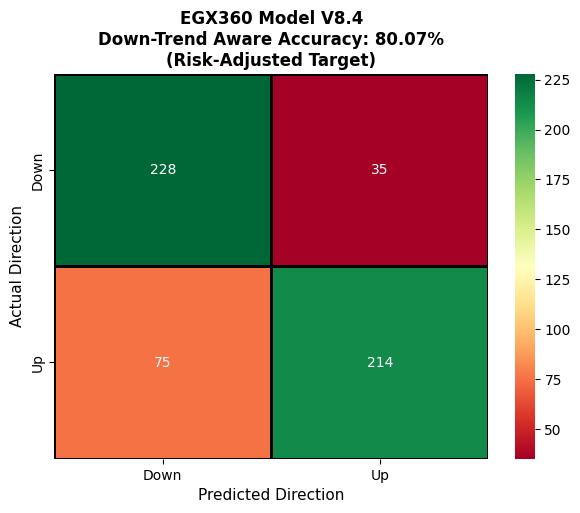

In [155]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'], linewidths=1, linecolor='black')
plt.title(f"EGX360 Model V8.4\nDown-Trend Aware Accuracy: {acc:.2f}%\n(Risk-Adjusted Target)", fontsize=12, fontweight='bold')
plt.xlabel('Predicted Direction', fontsize=11)
plt.ylabel('Actual Direction', fontsize=11)
plt.show()

## 8. Strategy Testing & Prediction Visualization (Signal Generation)
**Concept:** Accuracy metrics and Confusion Matrices are abstract. To truly validate a Quantitative Model, we must map its predictions back onto the chronological price chart. Here, we visualize the model's output on the unseen test data. 
* **Green Up-Triangles:** The model predicted the $EMA_{10}$ will rise (Buy/Hold Signal).
* **Red Down-Triangles:** The model predicted the $EMA_{10}$ will fall (Sell/Exit Signal).

By observing these signals against the actual price action, we can visually confirm if the model successfully avoids "Whipsaws" (false signals) and accurately rides the major trends.

### Create a DataFrame to map predictions back to dates and prices

In [156]:
### Create a DataFrame to map predictions back to dates and prices
test_dates = df['timestamp'].iloc[split:].reset_index(drop=True)
test_close = df['close'].iloc[split:].reset_index(drop=True)
test_ema10 = df['close'].ewm(span=10).mean().iloc[split:].reset_index(drop=True)

results_df = pd.DataFrame({
    'timestamp': test_dates,
    'close': test_close,
    'EMA_10': test_ema10,
    'Actual_Trend': y_test,
    'Predicted_Trend': y_pred_aggressive # <--- التعديل هنا: استخدام الإشارة الهجومية
})

In [157]:
results_df['Filtered_Trend'] = np.where(
    (results_df['Predicted_Trend'] == 1) & (results_df['close'] < test_sma200),
    0, 
    results_df['Predicted_Trend']
)

# --- 2. حساب توقعات السعر لليوم التالي (Next Day Range Prediction) ---
# الموديل بيقول الاتجاه، والـ ATR بيحدد "الوسع" السعري المتوقع
# نضرب في 1.5 عشان ندي Range واقعي لحركة البيتكوين
results_df['Expected_High_Tomorrow'] = results_df['close'] + (test_atr_val * 1.5)
results_df['Expected_Low_Tomorrow'] = results_df['close'] - (test_atr_val * 1.5)

### To make the chart readable, we will visualize the last 150 days of the test set

In [158]:
viz_df = results_df.tail(150)

### Create the Interactive Plotly Figure

In [159]:
fig_test = go.Figure()

### 1. Plot the actual Close Price

In [160]:
fig_test.add_trace(go.Scatter(x=viz_df['timestamp'], y=viz_df['close'], 
                              mode='lines', name='Close Price', 
                              line=dict(color='rgba(128,128,128,0.5)', width=1.5)))

### 2. Plot the Target (EMA 10)

In [161]:
fig_test.add_trace(go.Scatter(x=viz_df['timestamp'], y=viz_df['EMA_10'], 
                              mode='lines', name='EMA 10 (Target)', 
                              line=dict(color='blue', width=2)))

### 3. Filter predictions for visualization

In [162]:
# 3. Filter predictions for visualization
buy_signals = viz_df[viz_df['Predicted_Trend'] == 1]
sell_signals = viz_df[viz_df['Predicted_Trend'] == 0]

### 4. Plot Model Predictions (Up = Green, Down = Red)

In [163]:
fig_test.add_trace(go.Scatter(x=buy_signals['timestamp'], y=buy_signals['EMA_10'], 
                              mode='markers', name='Model Signal: UP (1)', 
                              marker=dict(color='green', symbol='triangle-up', size=12, line=dict(width=1, color='darkgreen'))))

fig_test.add_trace(go.Scatter(x=sell_signals['timestamp'], y=sell_signals['EMA_10'], 
                              mode='markers', name='Model Signal: DOWN (0)', 
                              marker=dict(color='red', symbol='triangle-down', size=12, line=dict(width=1, color='darkred'))))

# Formatting the Chart

In [164]:
fig_test.update_layout(title='EGX360 Live Signals: Model Predictions vs Actual Market (Test Set)',
                       yaxis_title='Price (EGP)',
                       xaxis_title='Date',
                       template='plotly_white',
                       hovermode='x unified')
fig_test.show()

## 9. Strategy Backtesting & Financial Performance (ROI)
**Concept:** A high predictive accuracy is only valuable if it translates into excess financial returns (Alpha). Here, we simulate a realistic trading environment starting with 10,000 EGP. 

**Backtesting Rules to Prevent Look-Ahead Bias:**
1. The model uses today's closing data to predict tomorrow's $EMA_{10}$ direction.
2. If the prediction is UP (1), we hold the asset for tomorrow.
3. If the prediction is DOWN (0), we sell at today's close and hold cash tomorrow (0% market return).
4. We compare our strategy's cumulative returns against a standard "Buy and Hold" baseline.

## 1. Initial Setup


In [165]:
initial_capital = 10000.0


### Calculate actual daily percentage returns of the closing price


In [166]:
results_df['daily_return'] = results_df['close'].pct_change()


### CRITICAL: Shift the signal by 1 day to prevent look-ahead bias.
### If the model predicts '1' today, we are IN the market tomorrow.

In [167]:
results_df['signal'] = results_df['Predicted_Trend'].shift(1)


In [182]:
# --- فكرة الـ Dynamic Hysteresis (الدخول الذكي) ---
signals = []
in_market = False

# هنسحب الـ EMA 50 عشان نعرف حالة السوق العامة
test_close_prices = df['close'].iloc[split:].reset_index(drop=True)
test_ema50 = df['EMA_50'].iloc[split:].reset_index(drop=True)

for i, prob in enumerate(y_probs):
    current_close = test_close_prices.iloc[i]
    current_ema50 = test_ema50.iloc[i]
    
    # تحديد عتبة الدخول بذكاء: هجومي في الصعود، ومحافظ في الهبوط
    dynamic_entry = 0.42 if current_close > current_ema50 else 0.50
    
    if not in_market:
        # لو إحنا بره السوق: الدخول حسب العتبة الديناميكية
        if prob >= dynamic_entry:
            in_market = True
            signals.append(1)
        else:
            signals.append(0)
    else:
        # لو إحنا جوه السوق: مش هنخرج غير لو حصل انهيار صريح في الاحتمالات (< 0.32)
        if prob < 0.32:
            in_market = False
            signals.append(0)
        else:
            signals.append(1)

# تطبيق الإشارات على الباك تيست
results_df['signal'] = pd.Series(signals, index=results_df.index).shift(1)
results_df['strategy_return'] = results_df['daily_return'] * results_df['signal']
bt_df = results_df.dropna().copy()

## 2. Strategy Return Calculation
### We only earn the daily return if our signal for that day was 1 (Hold). Otherwise, we earn 0 (Cash).

In [183]:

# وتكمل حساباتك عادي جداً
results_df['strategy_return'] = results_df['daily_return'] * results_df['signal']
bt_df = results_df.dropna().copy()

### Drop the first row which will have NaNs due to shifting/pct_change


In [184]:
bt_df = results_df.dropna().copy()


## 3. Cumulative Returns


In [185]:
bt_df['cumulative_market'] = (1 + bt_df['daily_return']).cumprod()
bt_df['cumulative_strategy'] = (1 + bt_df['strategy_return']).cumprod()


## 4. Monetary Value Tracking


In [186]:
bt_df['portfolio_value'] = initial_capital * bt_df['cumulative_strategy']
bt_df['bh_value'] = initial_capital * bt_df['cumulative_market']


## 5. Final Metrics & Visualizing the Portfolio Growth



In [187]:

final_portfolio = bt_df['portfolio_value'].iloc[-1]
final_bh = bt_df['bh_value'].iloc[-1]

strategy_profit_pct = ((final_portfolio - initial_capital) / initial_capital) * 100
market_profit_pct = ((final_bh - initial_capital) / initial_capital) * 100

print(f" Initial Capital: {initial_capital:,.2f} EGP")
print("-" * 40)
print(f"1) Buy & Hold Strategy (Market): {final_bh:,.2f} EGP ({market_profit_pct:.2f}%)")
print(f"2) EGX360 Strategy (Model):      {final_portfolio:,.2f} EGP ({strategy_profit_pct:.2f}%)")
print("-" * 40)
outperformance = strategy_profit_pct - market_profit_pct
print(f" The EGX360 Model outperformed the market by: {outperformance:.2f}%")

fig_bt = go.Figure()

# Plot Model Strategy Portfolio
fig_bt.add_trace(go.Scatter(x=bt_df['timestamp'], y=bt_df['portfolio_value'], 
                            mode='lines', name='EGX360 Strategy', 
                            line=dict(color='green', width=2.5)))

# Plot Buy & Hold Portfolio
fig_bt.add_trace(go.Scatter(x=bt_df['timestamp'], y=bt_df['bh_value'], 
                            mode='lines', name='Buy & Hold Baseline', 
                            line=dict(color='gray', width=1.5, dash='dash')))

fig_bt.update_layout(title='EGX360 Financial Backtest: Portfolio Growth (10,000 EGP Initial)',
                     yaxis_title='Portfolio Value (EGP)',
                     xaxis_title='Date',
                     template='plotly_white',
                     hovermode='x unified')
fig_bt.show()


 Initial Capital: 10,000.00 EGP
----------------------------------------
1) Buy & Hold Strategy (Market): 12,021.58 EGP (20.22%)
2) EGX360 Strategy (Model):      15,231.76 EGP (52.32%)
----------------------------------------
 The EGX360 Model outperformed the market by: 32.10%


In [174]:
importances = stack_model.named_estimators_['xgb'].feature_importances_

In [175]:
# --- كود اختبار وتأكيد أرقام النطاق السعري (Price Range Tester) ---
print("\n🔍 Testing Expected Price Range vs Actual Market (Last 7 Days) 🔍\n")

# بناخد نسخة من التوقعات
test_range_df = results_df[['timestamp', 'close', 'Predicted_Trend', 'Expected_High_Tomorrow', 'Expected_Low_Tomorrow']].copy()

# بنجيب أعلى وأقل سعر حقيقي لليوم اللي بعده (عشان المقارنة)
actual_highs = df['high'].iloc[split:].reset_index(drop=True)
actual_lows = df['low'].iloc[split:].reset_index(drop=True)

test_range_df['Actual_High_Tomorrow'] = actual_highs.shift(-1)
test_range_df['Actual_Low_Tomorrow'] = actual_lows.shift(-1)

# هنعرض آخر 7 أيام في الداتا
display_df = test_range_df.tail(8).dropna()

for index, row in display_df.iterrows():
    date = row['timestamp'].strftime('%Y-%m-%d')
    trend = "🟢 UP (Buy)" if row['Predicted_Trend'] == 1 else "🔴 DOWN (Cash)"
    
    print(f"📅 Date: {date} | Close Today: {row['close']:,.2f}")
    print(f"   🤖 Signal Tomorrow: {trend}")
    print(f"   🎯 Expected Range : {row['Expected_Low_Tomorrow']:,.2f}  <--->  {row['Expected_High_Tomorrow']:,.2f}")
    print(f"   📊 ACTUAL Range   : {row['Actual_Low_Tomorrow']:,.2f}  <--->  {row['Actual_High_Tomorrow']:,.2f}")
    print("-" * 65)


🔍 Testing Expected Price Range vs Actual Market (Last 7 Days) 🔍

📅 Date: 2026-02-27 | Close Today: 65,881.80
   🤖 Signal Tomorrow: 🔴 DOWN (Cash)
   🎯 Expected Range : 62,022.45  <--->  69,741.14
   📊 ACTUAL Range   : 63,062.22  <--->  67,714.52
-----------------------------------------------------------------
📅 Date: 2026-02-28 | Close Today: 66,995.86
   🤖 Signal Tomorrow: 🟢 UP (Buy)
   🎯 Expected Range : 62,828.18  <--->  71,163.54
   📊 ACTUAL Range   : 65,076.73  <--->  68,162.82
-----------------------------------------------------------------
📅 Date: 2026-03-01 | Close Today: 65,738.10
   🤖 Signal Tomorrow: 🔴 DOWN (Cash)
   🎯 Expected Range : 61,549.07  <--->  69,927.14
   📊 ACTUAL Range   : 65,303.14  <--->  70,044.00
-----------------------------------------------------------------
📅 Date: 2026-03-02 | Close Today: 68,775.85
   🤖 Signal Tomorrow: 🟢 UP (Buy)
   🎯 Expected Range : 64,375.19  <--->  73,176.52
   📊 ACTUAL Range   : 66,237.62  <--->  69,232.89
----------------------